# TruthLens — Research Paper Figures\n\nPublication-quality visualizations for the TruthLens misinformation detection system.\nAll figures saved as PNG (300 DPI) and PDF to the `viz/` directory.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Style ──────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Color palette ──────────────────────────────────────────────────────
MODEL_COLORS = {
    "Baseline RoBERTa":      "#2274A5",
    "Baseline MLM":          "#F75C03",
    "Two-Phase MLM":         "#2ECC71",
    "Two-Phase RoBERTa":     "#9B59B6",
    "Two-Phase Distil":      "#E74C3C",
}
LABEL_COLORS = {"False": "#E74C3C", "True": "#2ECC71"}
METRIC_COLORS = {"Macro-F1": "#2274A5", "Accuracy": "#F75C03", "1 − ECE": "#2ECC71"}

VIZ_DIR = Path(".")  # notebook lives in viz/
BASE = Path("..") / "baseline_model" / "baseline_outputs"
DATA_DIR = Path("..") / "data" / "processed" / "final_datasets"

def save_fig(fig, name):
    fig.savefig(VIZ_DIR / f"{name}.png")
    fig.savefig(VIZ_DIR / f"{name}.pdf")
    print(f"  Saved {name}.png and {name}.pdf")

print("Setup complete.")

Setup complete.


In [2]:
# ── Load training metrics ──────────────────────────────────────────────

PROJECT_ROOT = Path("..")

# v5 logs (max_length=256)
V5_MAP = {
    "Baseline RoBERTa":  BASE / "baseline_roberta"  / "logs" / "metrics_log.jsonl",
    "Baseline MLM":      BASE / "baseline_mlm"      / "logs" / "metrics_log.jsonl",
    "Two-Phase MLM":     BASE / "twophase_mlm"       / "logs" / "metrics_log.jsonl",
    "Two-Phase RoBERTa": BASE / "twophase_roberta"   / "logs" / "metrics_log.jsonl",
    "Two-Phase Distil":  BASE / "twophase_distil"    / "logs" / "metrics_log.jsonl",
}

# v6 logs (max_length=384, class weights [1.0, 1.5])
V6_MAP = {
    "Baseline RoBERTa":  PROJECT_ROOT / "baseline_roberta_384_metrics.jsonl",
    "Baseline MLM":      PROJECT_ROOT / "baseline_mlm_384_metrics.jsonl",
    "Two-Phase MLM":     PROJECT_ROOT / "twophase_mlm_384_metrics.jsonl",
    "Two-Phase RoBERTa": PROJECT_ROOT / "twophase_roberta_384_metrics.jsonl",
    "Two-Phase Distil":  PROJECT_ROOT / "twophase_distil_384_metrics.jsonl",
}


def _load_metrics(run_map):
    """Load JSONL metrics, returning (metrics_dict, efficiency_dict)."""
    metrics_out, eff_out = {}, {}
    for name, path in run_map.items():
        rows = []
        with open(path) as f:
            for line in f:
                obj = json.loads(line)
                if obj.get("type") == "efficiency":
                    eff_out[name] = obj
                else:
                    rows.append(obj)
        df = pd.DataFrame(rows)
        if "phase" in df.columns:
            p1 = df[df["phase"] == "Phase1"]
            max_p1 = p1["epoch"].max() if len(p1) > 0 else 0
            df.loc[df["phase"] == "Phase2", "global_epoch"] = (
                df.loc[df["phase"] == "Phase2", "epoch"] + max_p1
            )
            df.loc[df["phase"] == "Phase1", "global_epoch"] = df.loc[
                df["phase"] == "Phase1", "epoch"
            ]
            df["phase_boundary"] = max_p1
        else:
            df["global_epoch"] = df["epoch"]
            df["phase_boundary"] = None
        metrics_out[name] = df
    return metrics_out, eff_out


metrics_v5, efficiency_v5 = _load_metrics(V5_MAP)
metrics_v6, efficiency_v6 = _load_metrics(V6_MAP)

for ver, m in [("v5", metrics_v5), ("v6", metrics_v6)]:
    for name, df in m.items():
        print(f"  {ver} {name}: {len(df)} epochs, best F1={df['val_macro_f1'].max():.4f}")

# ── Load dataset ───────────────────────────────────────────────────────
dfs = {}
for split in ["train", "val", "test"]:
    dfs[split] = pd.read_parquet(DATA_DIR / f"unified_{split}.parquet")
    dfs[split]["split"] = split

dataset = pd.concat(dfs.values(), ignore_index=True)

SOURCE_MAP = {
    "coaid": "CoAID", "fakehealth": "FakeHealth",
    "fakenewsnet": "FakeNewsNet", "hover": "HOVER", "liar": "LIAR",
}
dataset["source"] = dataset["dataset"].map(SOURCE_MAP).fillna(dataset["dataset"])

print(f"\nLoaded {len(dataset)} samples across {dataset['source'].nunique()} sources.")

  v5 Baseline RoBERTa: 55 epochs, best F1=0.7470
  v5 Baseline MLM: 66 epochs, best F1=0.7468
  v5 Two-Phase MLM: 27 epochs, best F1=0.7429
  v5 Two-Phase RoBERTa: 52 epochs, best F1=0.7387
  v5 Two-Phase Distil: 17 epochs, best F1=0.7338
  v6 Baseline RoBERTa: 62 epochs, best F1=0.7435
  v6 Baseline MLM: 62 epochs, best F1=0.7453
  v6 Two-Phase MLM: 28 epochs, best F1=0.7419
  v6 Two-Phase RoBERTa: 25 epochs, best F1=0.7413
  v6 Two-Phase Distil: 22 epochs, best F1=0.7323



Loaded 56641 samples across 5 sources.


## Figure 1 — Dataset Composition by Source and Binary Label

  Saved fig1_dataset_composition.png and fig1_dataset_composition.pdf


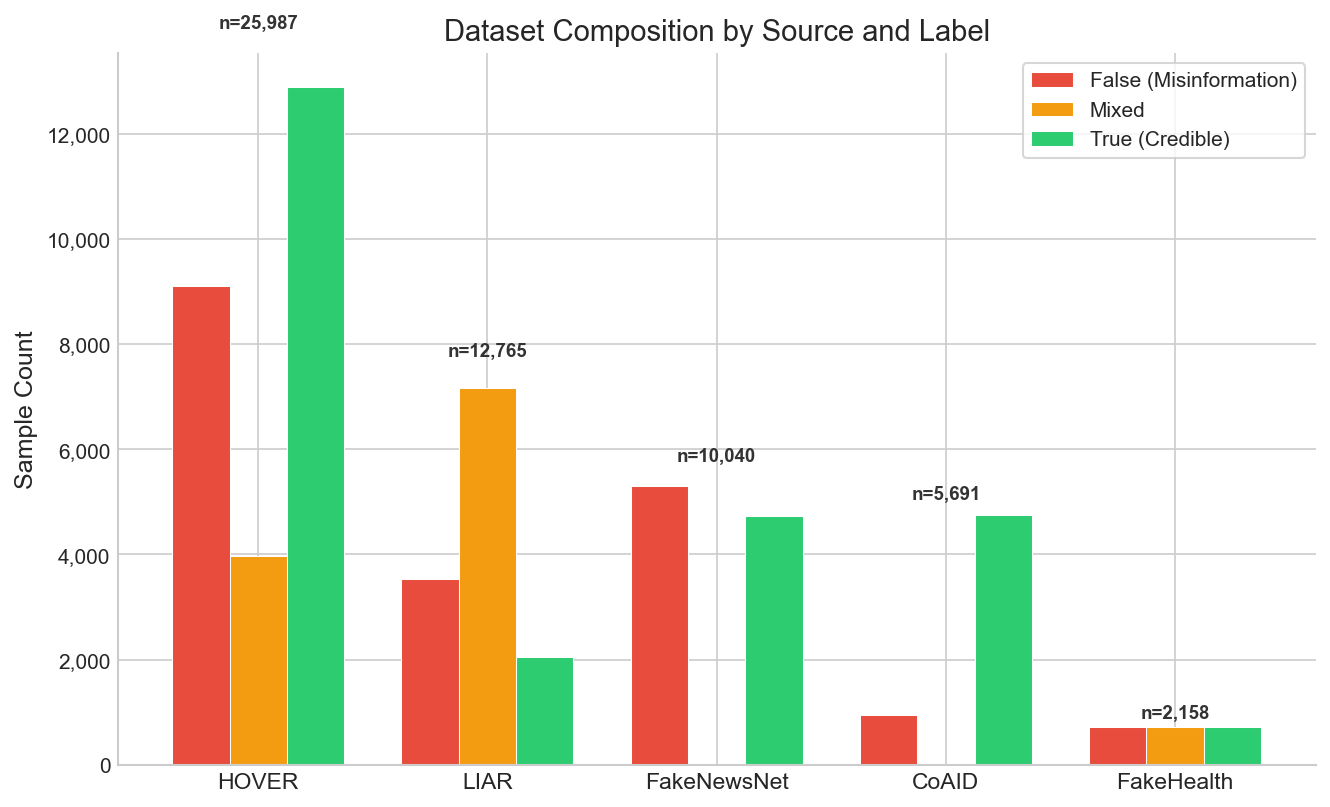

In [3]:
# For each source, use binary labels if available, otherwise use 3-way labels
# Binary: label_bin 0=False, 1=True
# 3-way:  label_3way 0=False, 1=Mixed, 2=True

categories = ["False", "Mixed", "True"]
cat_colors = ["#E74C3C", "#F39C12", "#2ECC71"]

records = []
for src in dataset["source"].unique():
    sub = dataset[dataset["source"] == src]
    has_binary = (sub["label_bin"] != -100).any()
    has_3way = (sub["label_3way"] != -100).any()

    if has_3way and not has_binary:
        # Use 3-way labels (LIAR, FakeHealth — no binary labels)
        valid = sub[sub["label_3way"] != -100]
        counts = valid["label_3way"].value_counts()
        records.append({
            "source": src,
            "False": counts.get(0, 0),
            "Mixed": counts.get(1, 0),
            "True":  counts.get(2, 0),
        })
    elif has_binary and not has_3way:
        # Use binary labels (FakeNewsNet — no 3-way labels)
        valid = sub[sub["label_bin"] != -100]
        counts = valid["label_bin"].value_counts()
        records.append({
            "source": src,
            "False": counts.get(0, 0),
            "Mixed": 0,
            "True":  counts.get(1, 0),
        })
    else:
        # Has both — use 3-way for the richer breakdown (HOVER, CoAID)
        valid = sub[sub["label_3way"] != -100]
        counts = valid["label_3way"].value_counts()
        records.append({
            "source": src,
            "False": counts.get(0, 0),
            "Mixed": counts.get(1, 0),
            "True":  counts.get(2, 0),
        })

ct = pd.DataFrame(records).set_index("source")[categories]
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(ct))
width = 0.25

for i, (col, color) in enumerate(zip(categories, cat_colors)):
    label_map = {"False": "False (Misinformation)", "Mixed": "Mixed", "True": "True (Credible)"}
    ax.bar(x + (i - 1) * width, ct[col], width, label=label_map[col],
           color=color, edgecolor="white", linewidth=0.5)

# Annotate totals
for i, src in enumerate(ct.index):
    total = ct.loc[src].sum()
    ax.text(i, ct.loc[src].max() + total * 0.04, f"n={total:,}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333")

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=11)
ax.set_ylabel("Sample Count")
ax.set_title("Dataset Composition by Source and Label")
ax.legend(frameon=True, fancybox=True, shadow=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

fig.tight_layout()
save_fig(fig, "fig1_dataset_composition")
plt.show()

## Figure 2 — Content Availability by Source

  Saved fig2_content_availability.png and fig2_content_availability.pdf


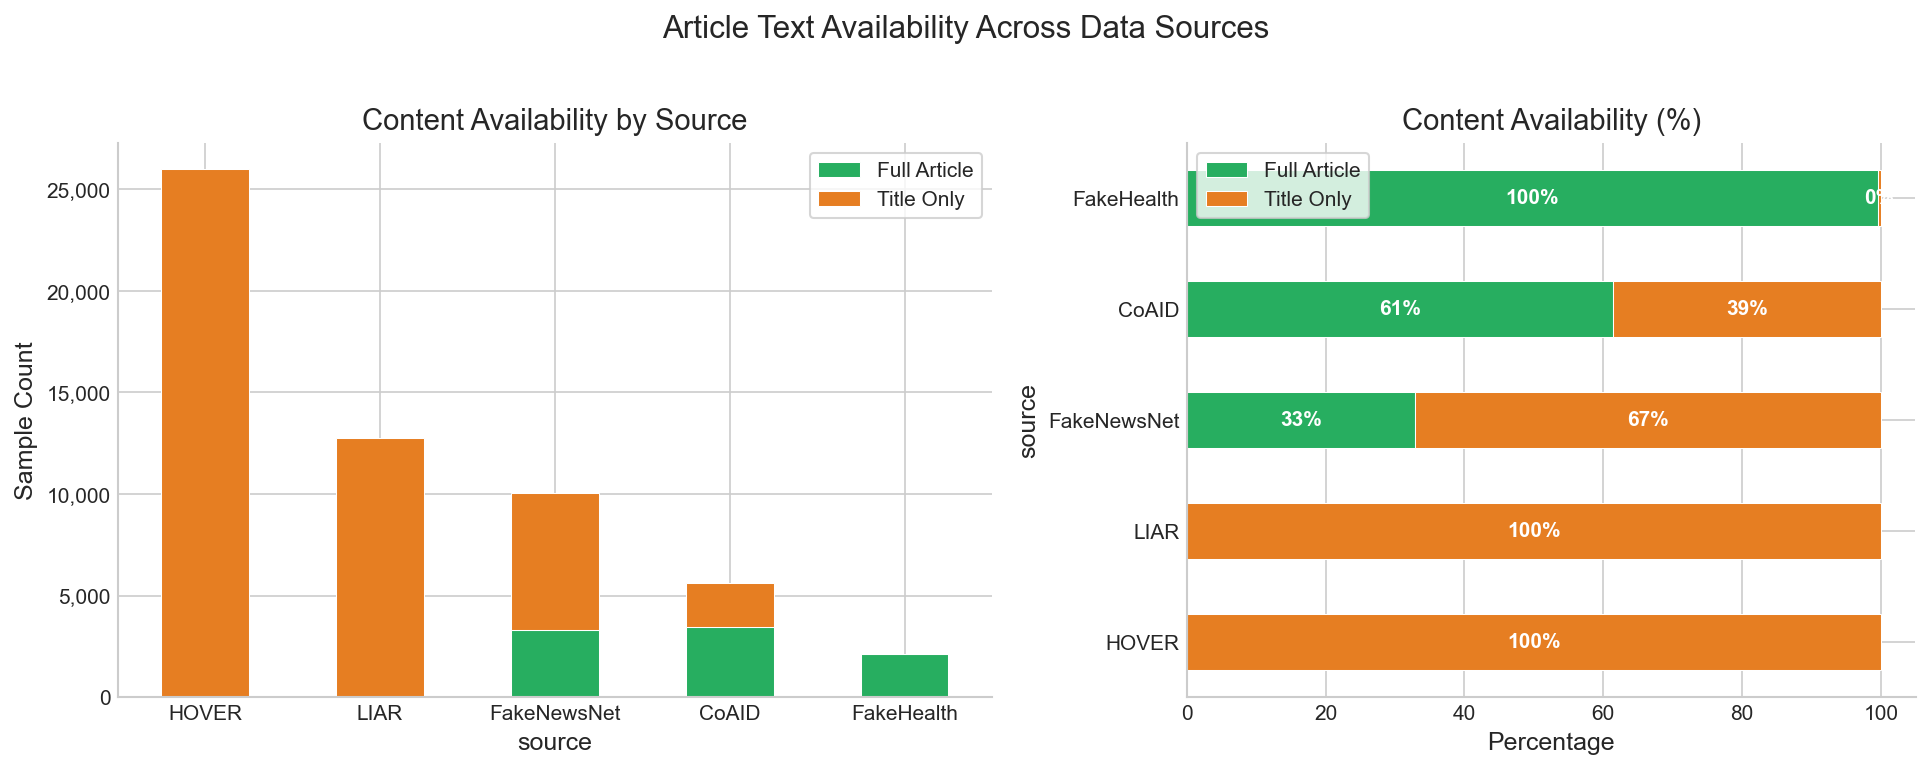

In [4]:
# Content availability: title_only vs full_article vs partial
status_map = {"title_only": "Title Only", "full_article": "Full Article", "partial_article": "Partial"}
dataset["content_label"] = dataset["content_status"].map(status_map).fillna("Other")

ct_content = pd.crosstab(dataset["source"], dataset["content_label"])
for col in ["Full Article", "Title Only", "Partial", "Other"]:
    if col not in ct_content.columns:
        ct_content[col] = 0
ct_content = ct_content[["Full Article", "Title Only"]]
# Sort by total descending
ct_content = ct_content.loc[ct_content.sum(axis=1).sort_values(ascending=False).index]

# Stacked bar — percentage
ct_pct = ct_content.div(ct_content.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.2, 1]})

# Left: absolute counts stacked
content_colors = ["#27AE60", "#E67E22"]
ct_content.plot.bar(stacked=True, ax=ax1, color=content_colors, edgecolor="white", linewidth=0.5)
ax1.set_ylabel("Sample Count")
ax1.set_title("Content Availability by Source")
ax1.set_xticklabels(ct_content.index, rotation=0, fontsize=10)
ax1.legend(frameon=True, fancybox=True)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Right: percentage stacked
ct_pct.plot.barh(stacked=True, ax=ax2, color=content_colors, edgecolor="white", linewidth=0.5)
for i, src in enumerate(ct_pct.index):
    full_pct = ct_pct.loc[src, "Full Article"]
    if full_pct > 3:
        ax2.text(full_pct / 2, i, f"{full_pct:.0f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
    title_pct = ct_pct.loc[src, "Title Only"]
    ax2.text(full_pct + title_pct / 2, i, f"{title_pct:.0f}%", ha="center", va="center",
             fontsize=10, fontweight="bold", color="white")

ax2.set_xlabel("Percentage")
ax2.set_title("Content Availability (%)")
ax2.legend(frameon=True, fancybox=True)

fig.suptitle("Article Text Availability Across Data Sources", fontsize=15, y=1.02)
fig.tight_layout()
save_fig(fig, "fig2_content_availability")
plt.show()

## Figure 3 — Validation Macro-F1 Learning Curves (v5 vs v6)

  Saved fig3_val_f1_curves.png and fig3_val_f1_curves.pdf


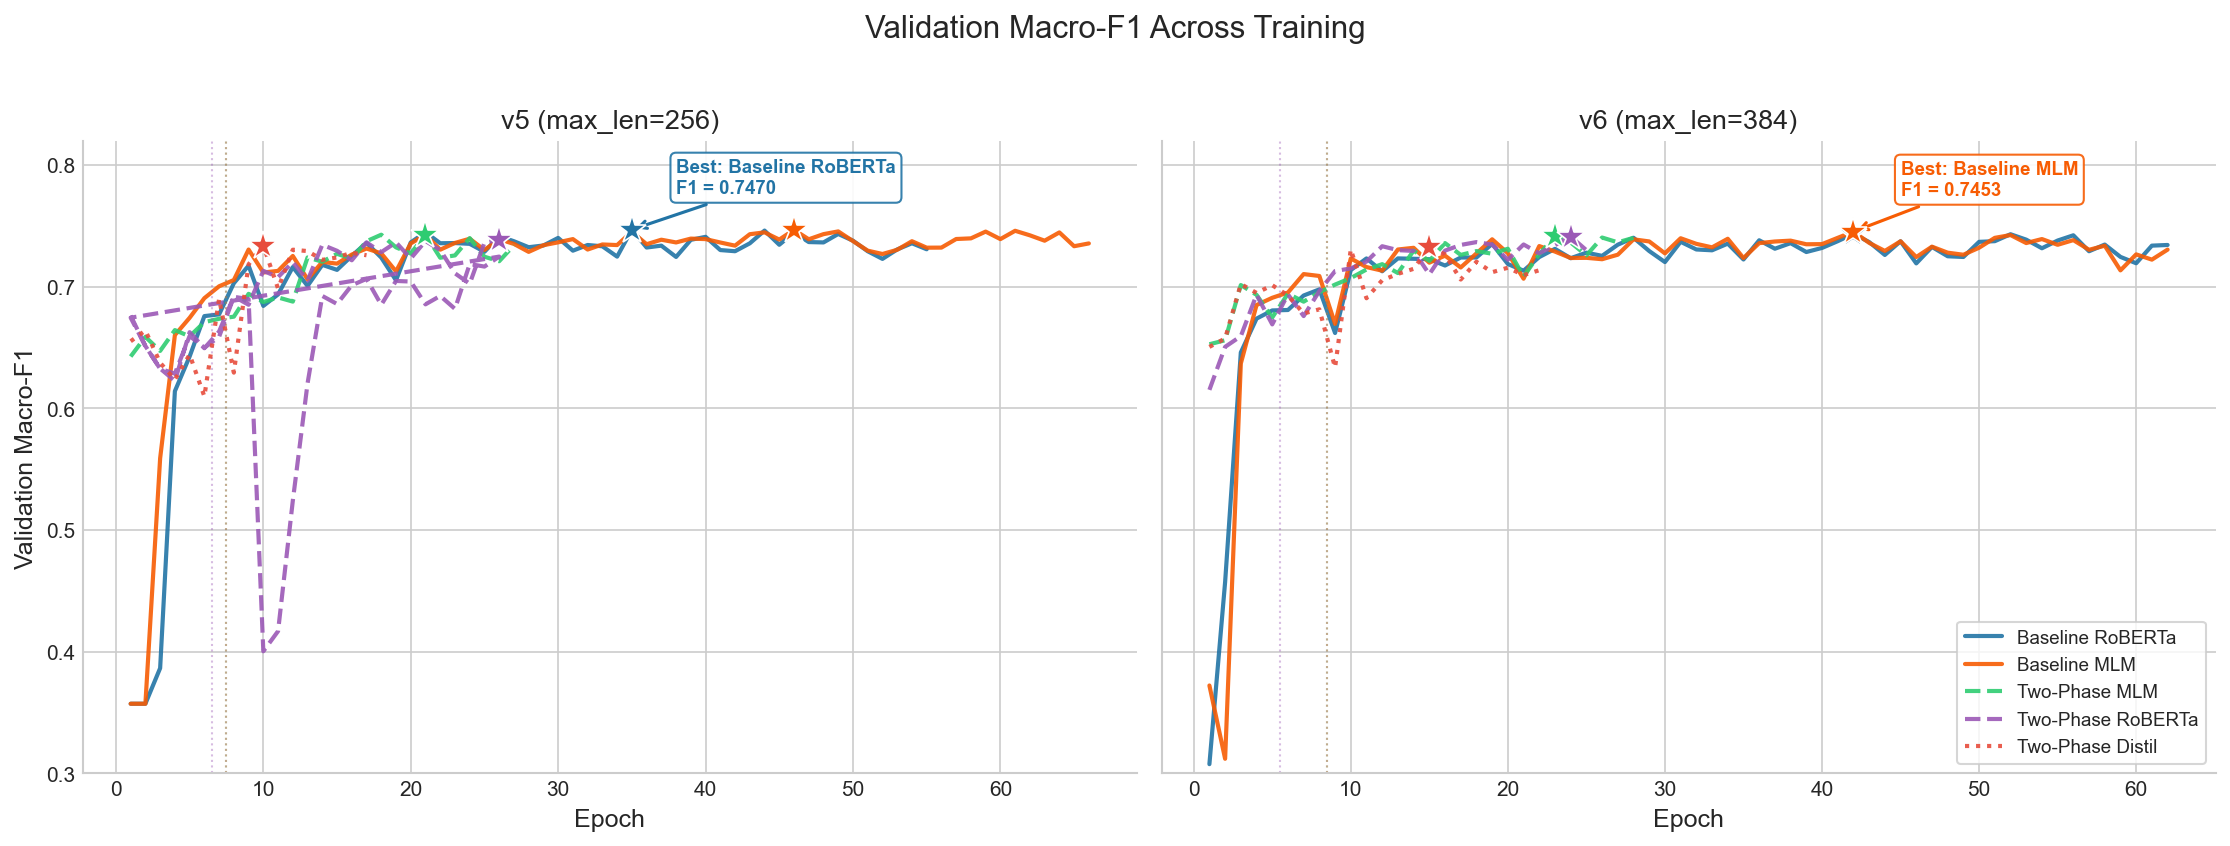

In [5]:
fig, (ax_v5, ax_v6) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

line_styles = {
    "Baseline RoBERTa": "-", "Baseline MLM": "-",
    "Two-Phase MLM": "--", "Two-Phase RoBERTa": "--", "Two-Phase Distil": ":",
}

for ax, metrics_ver, ver_label in [(ax_v5, metrics_v5, "v5 (max_len=256)"),
                                    (ax_v6, metrics_v6, "v6 (max_len=384)")]:
    best_name, best_f1, best_ep = None, 0, 0
    for name, df in metrics_ver.items():
        ax.plot(df["global_epoch"], df["val_macro_f1"],
                label=name, color=MODEL_COLORS[name],
                linestyle=line_styles[name], linewidth=2, alpha=0.9)
        idx = df["val_macro_f1"].idxmax()
        ep, f1 = df.loc[idx, "global_epoch"], df.loc[idx, "val_macro_f1"]
        ax.plot(ep, f1, marker="*", markersize=14, color=MODEL_COLORS[name],
                markeredgecolor="white", markeredgewidth=0.8, zorder=5)
        if f1 > best_f1:
            best_f1, best_name, best_ep = f1, name, ep
        pb = df["phase_boundary"].iloc[0]
        if pb is not None:
            ax.axvline(x=pb + 0.5, color=MODEL_COLORS[name], linestyle=":", linewidth=1, alpha=0.4)

    ax.annotate(f"Best: {best_name}\nF1 = {best_f1:.4f}",
                xy=(best_ep, best_f1),
                xytext=(best_ep + 3, best_f1 + 0.03),
                fontsize=9, fontweight="bold", color=MODEL_COLORS[best_name],
                arrowprops=dict(arrowstyle="->", color=MODEL_COLORS[best_name], lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=MODEL_COLORS[best_name], alpha=0.9))
    ax.set_xlabel("Epoch")
    ax.set_title(ver_label, fontsize=13)

ax_v5.set_ylabel("Validation Macro-F1")
ax_v5.set_ylim(0.30, 0.82)
ax_v6.legend(loc="lower right", frameon=True, fancybox=True, fontsize=9)
fig.suptitle("Validation Macro-F1 Across Training", fontsize=15, y=1.02)
fig.tight_layout()
save_fig(fig, "fig3_val_f1_curves")
plt.show()

## Figure 4 — Training & Validation Loss (v5 vs v6)

  Saved fig4_loss_curves.png and fig4_loss_curves.pdf


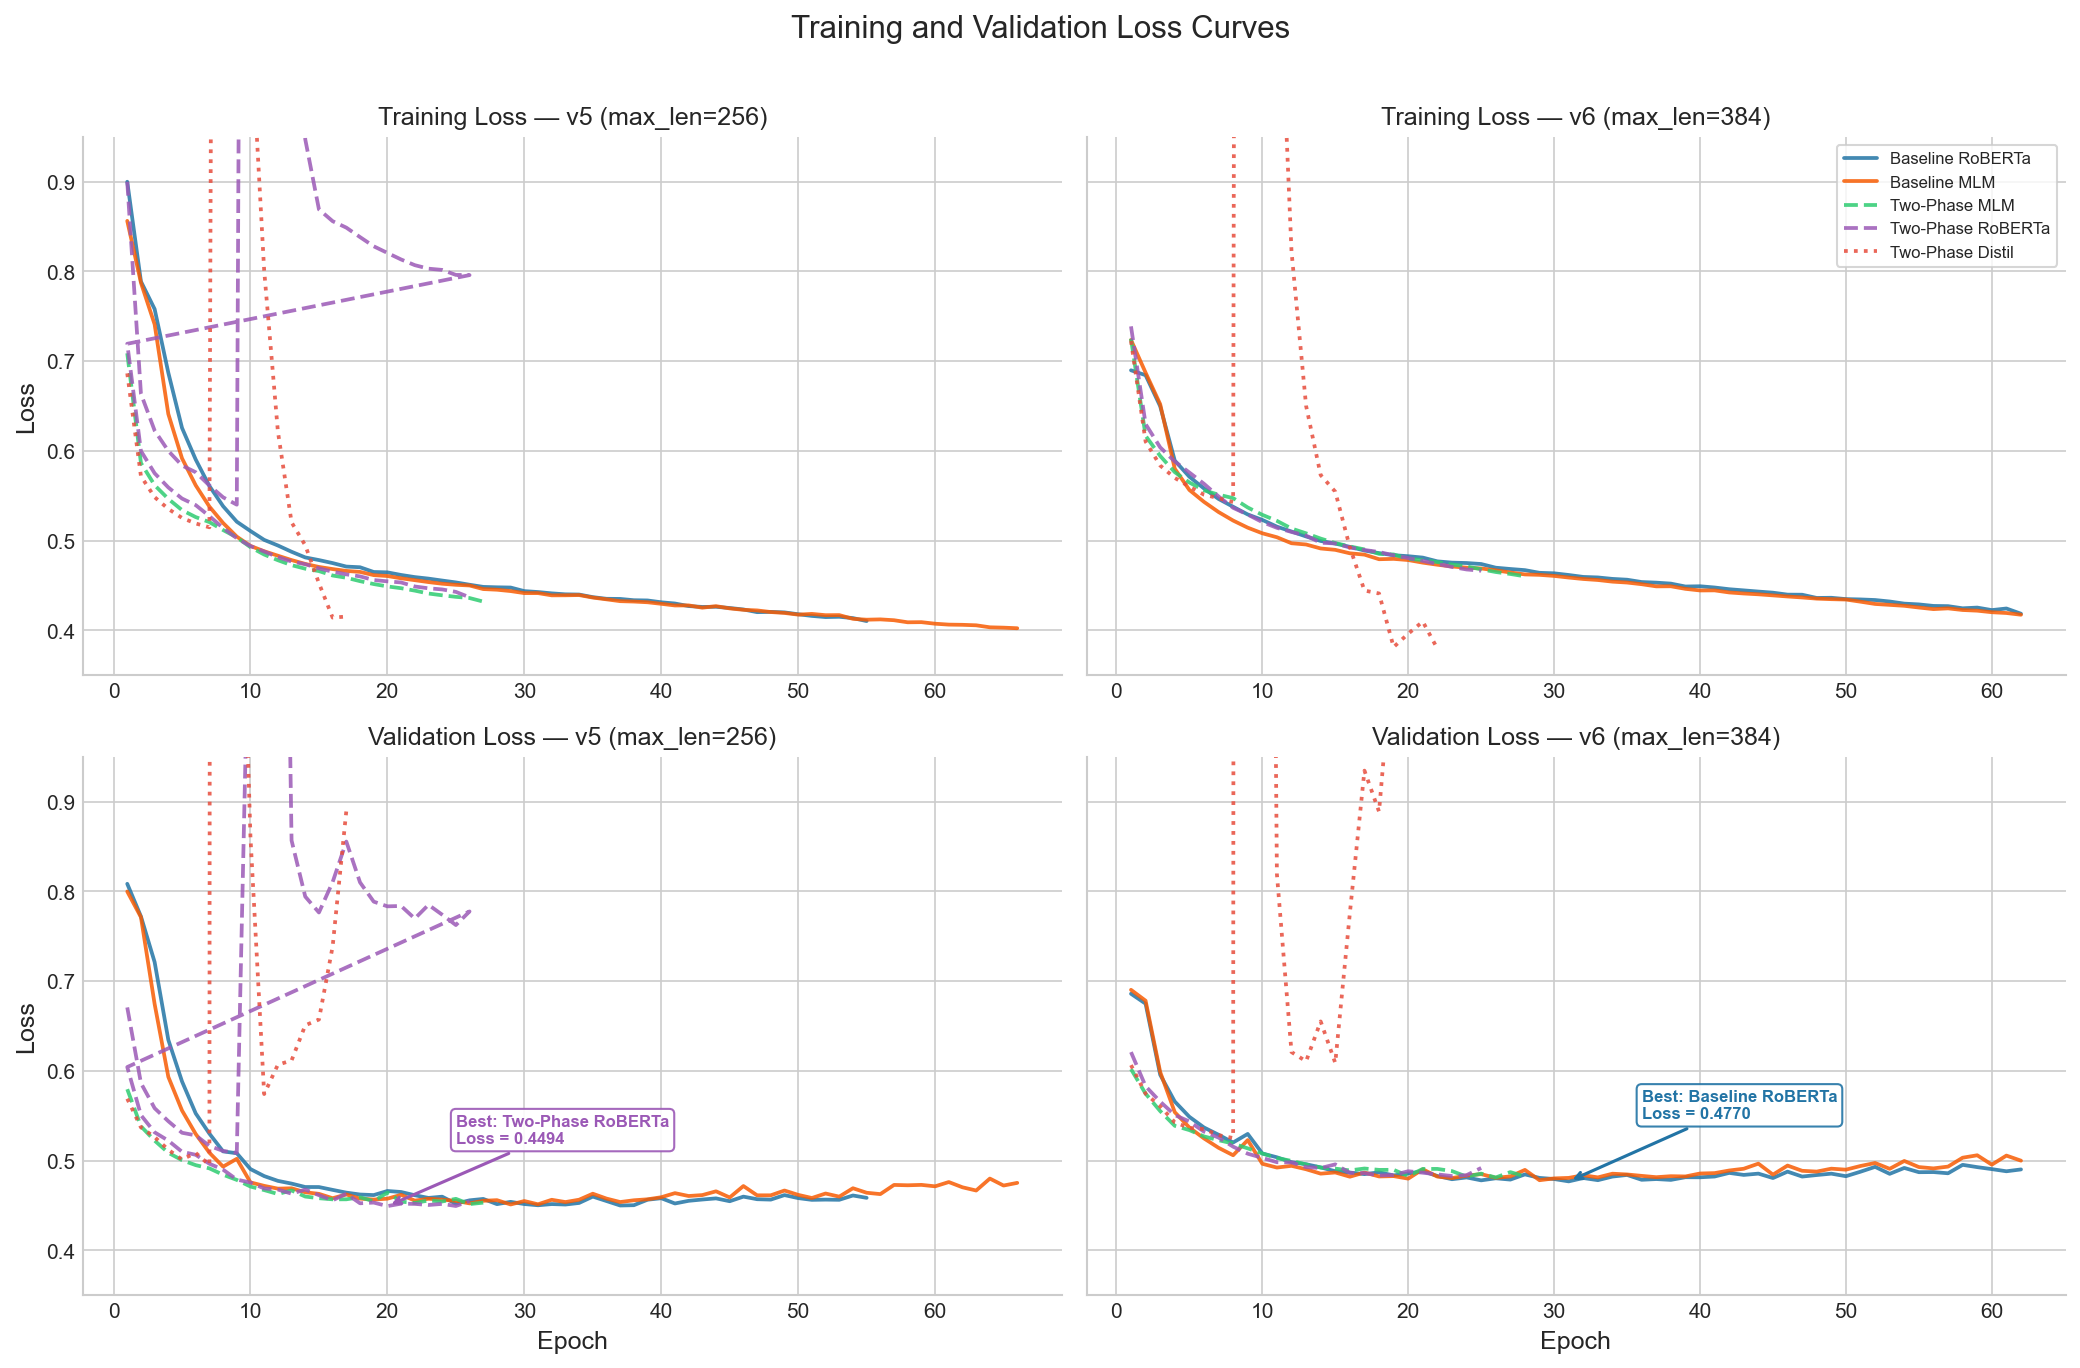

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey="row")

for col, (metrics_ver, ver_label) in enumerate([(metrics_v5, "v5 (max_len=256)"),
                                                  (metrics_v6, "v6 (max_len=384)")]):
    ax_train, ax_val = axes[0, col], axes[1, col]
    best_val_loss, best_name, best_ep = float("inf"), None, 0

    for name, df in metrics_ver.items():
        ls = line_styles[name]
        ax_train.plot(df["global_epoch"], df["train_loss"], label=name,
                      color=MODEL_COLORS[name], linestyle=ls, linewidth=1.8, alpha=0.85)
        ax_val.plot(df["global_epoch"], df["val_loss"], label=name,
                    color=MODEL_COLORS[name], linestyle=ls, linewidth=1.8, alpha=0.85)
        min_v = df["val_loss"].min()
        if min_v < best_val_loss:
            best_val_loss = min_v
            best_name = name
            best_ep = df.loc[df["val_loss"].idxmin(), "global_epoch"]

    ax_val.annotate(f"Best: {best_name}\nLoss = {best_val_loss:.4f}",
                    xy=(best_ep, best_val_loss),
                    xytext=(best_ep + 5, best_val_loss + 0.07),
                    fontsize=8, fontweight="bold", color=MODEL_COLORS[best_name],
                    arrowprops=dict(arrowstyle="->", color=MODEL_COLORS[best_name], lw=1.5),
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=MODEL_COLORS[best_name], alpha=0.9))

    ax_train.set_title(f"Training Loss — {ver_label}", fontsize=12)
    ax_val.set_title(f"Validation Loss — {ver_label}", fontsize=12)
    ax_val.set_xlabel("Epoch")

    if col == 1:
        ax_train.legend(loc="upper right", frameon=True, fancybox=True, fontsize=8)

axes[0, 0].set_ylabel("Loss")
axes[1, 0].set_ylabel("Loss")
for ax in axes.flat:
    ax.set_ylim(0.35, 0.95)

fig.suptitle("Training and Validation Loss Curves", fontsize=15, y=1.01)
fig.tight_layout()
save_fig(fig, "fig4_loss_curves")
plt.show()

## Figure 5 — Final Model Comparison: v5 vs v6

  Saved fig5_model_comparison.png and fig5_model_comparison.pdf


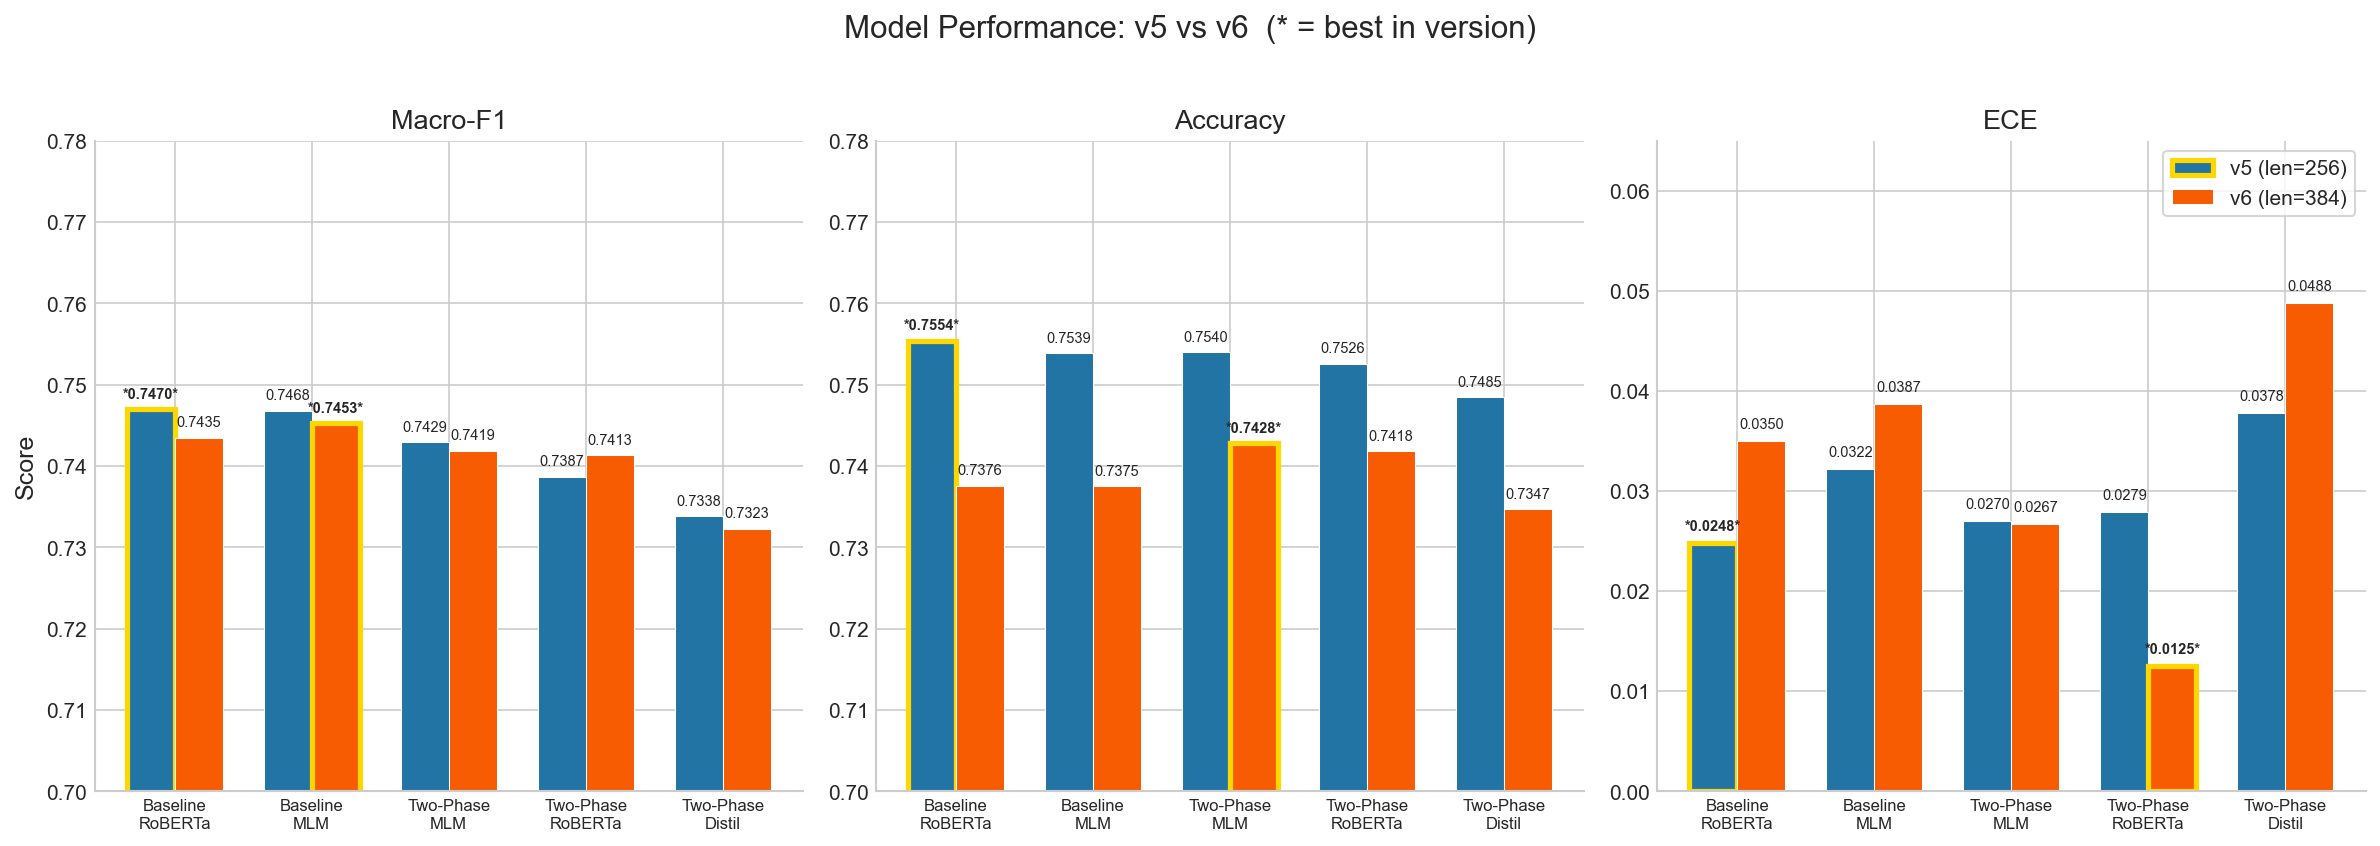

In [7]:
# v5 and v6 results from EXPERIMENTS.md
model_names = ["Baseline\nRoBERTa", "Baseline\nMLM", "Two-Phase\nMLM", "Two-Phase\nRoBERTa", "Two-Phase\nDistil"]

v5_f1  = [0.7470, 0.7468, 0.7429, 0.7387, 0.7338]
v5_acc = [0.7554, 0.7539, 0.7540, 0.7526, 0.7485]
v5_ece = [0.0248, 0.0322, 0.0270, 0.0279, 0.0378]

v6_f1  = [0.7435, 0.7453, 0.7419, 0.7413, 0.7323]
v6_acc = [0.7376, 0.7375, 0.7428, 0.7418, 0.7347]
v6_ece = [0.0350, 0.0387, 0.0267, 0.0125, 0.0488]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5.5))
x = np.arange(len(model_names))
width = 0.35
v5_color, v6_color = "#2274A5", "#F75C03"

for ax, v5_vals, v6_vals, metric, lower_better in [
    (ax1, v5_f1, v6_f1, "Macro-F1", False),
    (ax2, v5_acc, v6_acc, "Accuracy", False),
    (ax3, v5_ece, v6_ece, "ECE", True),
]:
    b1 = ax.bar(x - width/2, v5_vals, width, label="v5 (len=256)", color=v5_color,
                edgecolor="white", linewidth=0.5)
    b2 = ax.bar(x + width/2, v6_vals, width, label="v6 (len=384)", color=v6_color,
                edgecolor="white", linewidth=0.5)

    # Find best in each version
    if lower_better:
        best_v5, best_v6 = int(np.argmin(v5_vals)), int(np.argmin(v6_vals))
    else:
        best_v5, best_v6 = int(np.argmax(v5_vals)), int(np.argmax(v6_vals))

    for j, (bar5, bar6) in enumerate(zip(b1, b2)):
        for bar, is_best in [(bar5, j == best_v5), (bar6, j == best_v6)]:
            txt = f"{bar.get_height():.4f}"
            w = "bold" if is_best else "normal"
            if is_best:
                txt = f"*{txt}*"
                bar.set_edgecolor("#FFD700")
                bar.set_linewidth(2.5)
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    txt, ha="center", va="bottom", fontsize=7, fontweight=w)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=8)
    ax.set_title(metric, fontsize=13)

    if metric == "ECE":
        ax.set_ylim(0, 0.065)
    else:
        ax.set_ylim(0.70, 0.78)

ax1.set_ylabel("Score")
ax3.legend(frameon=True, fancybox=True, fontsize=10)
fig.suptitle("Model Performance: v5 vs v6  (* = best in version)", fontsize=15, y=1.02)
fig.tight_layout()
save_fig(fig, "fig5_model_comparison")
plt.show()

## Figure 6 — Per-Class Precision, Recall, and F1 (v5 vs v6)

  Saved fig6_per_class_metrics.png and fig6_per_class_metrics.pdf


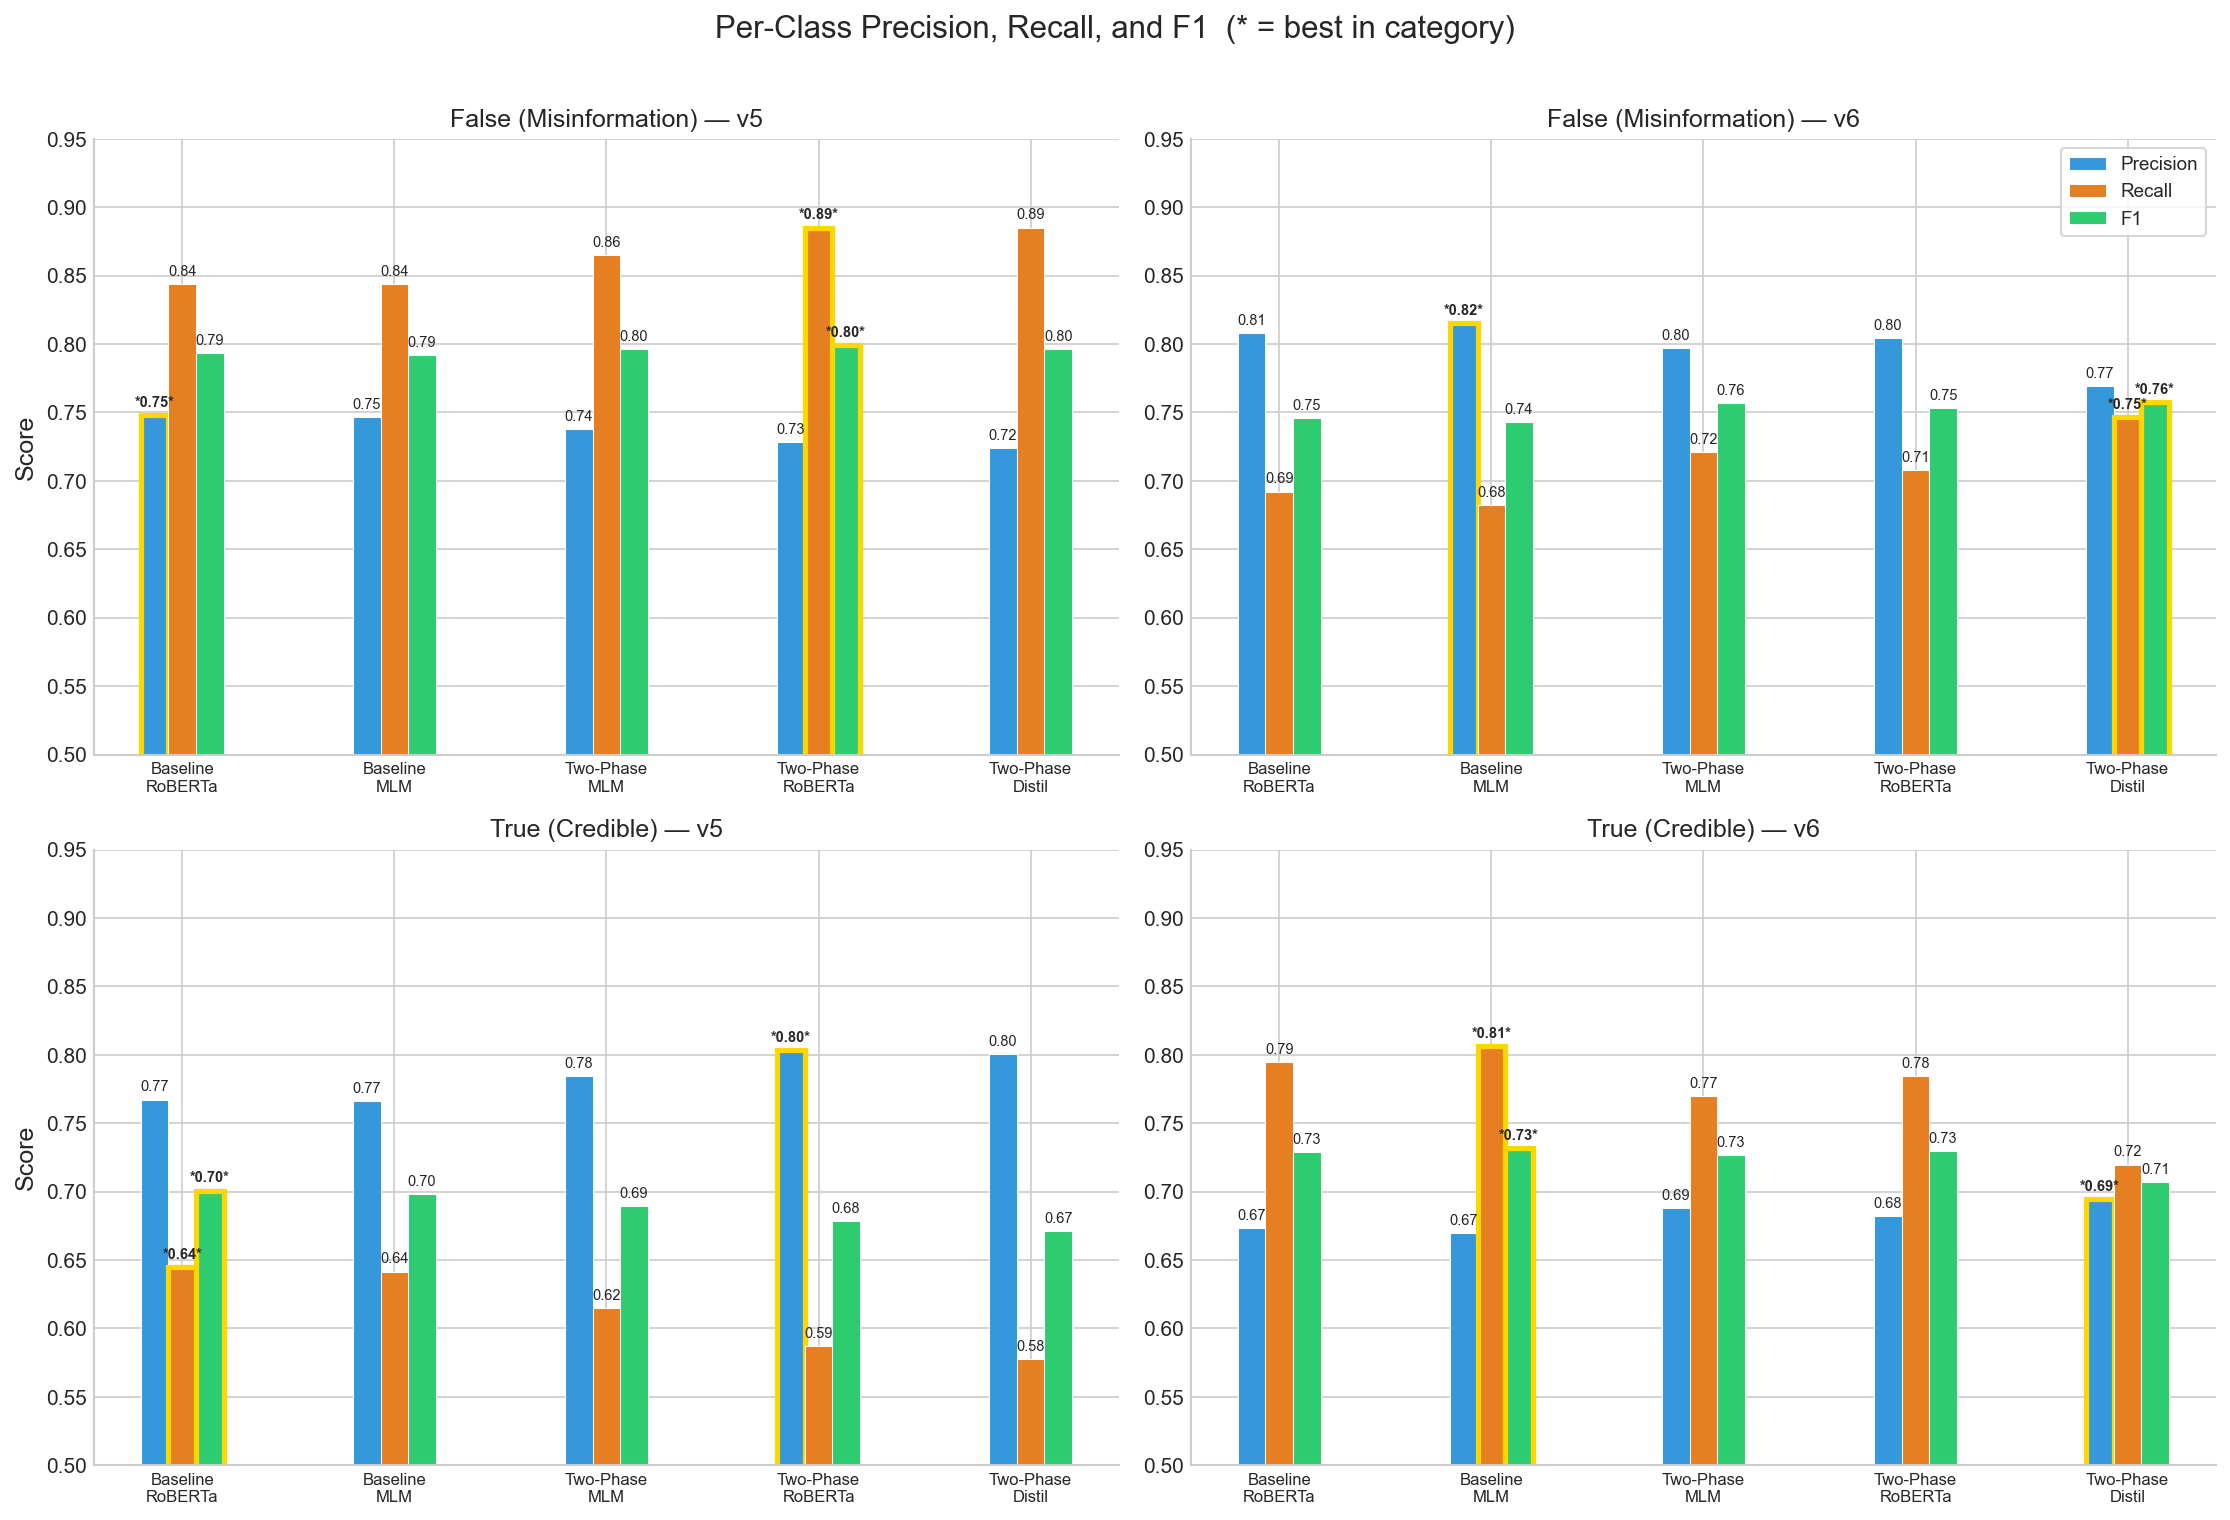

In [8]:
# Per-class metrics from EXPERIMENTS.md
models_short = ["Baseline\nRoBERTa", "Baseline\nMLM", "Two-Phase\nMLM", "Two-Phase\nRoBERTa", "Two-Phase\nDistil"]

per_class_v5 = {
    "false_P": [0.7483, 0.7465, 0.7376, 0.7284, 0.7239], "false_R": [0.8437, 0.8437, 0.8650, 0.8850, 0.8850],
    "false_F1": [0.7931, 0.7921, 0.7963, 0.7991, 0.7964],
    "true_P": [0.7673, 0.7664, 0.7845, 0.8032, 0.8006], "true_R": [0.6449, 0.6415, 0.6151, 0.5870, 0.5777],
    "true_F1": [0.7008, 0.6984, 0.6895, 0.6783, 0.6711],
}
per_class_v6 = {
    "false_P": [0.8082, 0.8152, 0.7968, 0.8042, 0.7693], "false_R": [0.6922, 0.6823, 0.7211, 0.7078, 0.7467],
    "false_F1": [0.7457, 0.7429, 0.7570, 0.7529, 0.7578],
    "true_P": [0.6735, 0.6699, 0.6881, 0.6820, 0.6943], "true_R": [0.7945, 0.8064, 0.7699, 0.7844, 0.7198],
    "true_F1": [0.7290, 0.7318, 0.7267, 0.7296, 0.7068],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
x = np.arange(len(models_short))
width = 0.13
prf_colors = ["#3498DB", "#E67E22", "#2ECC71"]

for row, (cls_label, prefix) in enumerate([("False (Misinformation)", "false"), ("True (Credible)", "true")]):
    for col, (pc, ver_label) in enumerate([(per_class_v5, "v5"), (per_class_v6, "v6")]):
        ax = axes[row, col]
        for i, (suffix, label) in enumerate(zip(["_P", "_R", "_F1"], ["Precision", "Recall", "F1"])):
            vals = pc[prefix + suffix]
            best_j = int(np.argmax(vals))
            bars = ax.bar(x + (i - 1) * width, vals, width, label=label,
                          color=prf_colors[i], edgecolor="white", linewidth=0.5)
            for j, bar in enumerate(bars):
                is_best = (j == best_j)
                txt = f"{bar.get_height():.2f}"
                if is_best:
                    txt = f"*{txt}*"
                    bar.set_edgecolor("#FFD700")
                    bar.set_linewidth(2.5)
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                        txt, ha="center", va="bottom", fontsize=7,
                        fontweight="bold" if is_best else "normal")

        ax.set_xticks(x)
        ax.set_xticklabels(models_short, fontsize=8)
        ax.set_title(f"{cls_label} — {ver_label}", fontsize=12)
        ax.set_ylim(0.50, 0.95)
        if col == 0:
            ax.set_ylabel("Score")
        if row == 0 and col == 1:
            ax.legend(frameon=True, fancybox=True, fontsize=9)

fig.suptitle("Per-Class Precision, Recall, and F1  (* = best in category)", fontsize=15, y=1.01)
fig.tight_layout()
save_fig(fig, "fig6_per_class_metrics")
plt.show()

## Figure 7 — Calibration (ECE) v5 vs v6 and Inference Efficiency

  Saved fig7_calibration_efficiency.png and fig7_calibration_efficiency.pdf


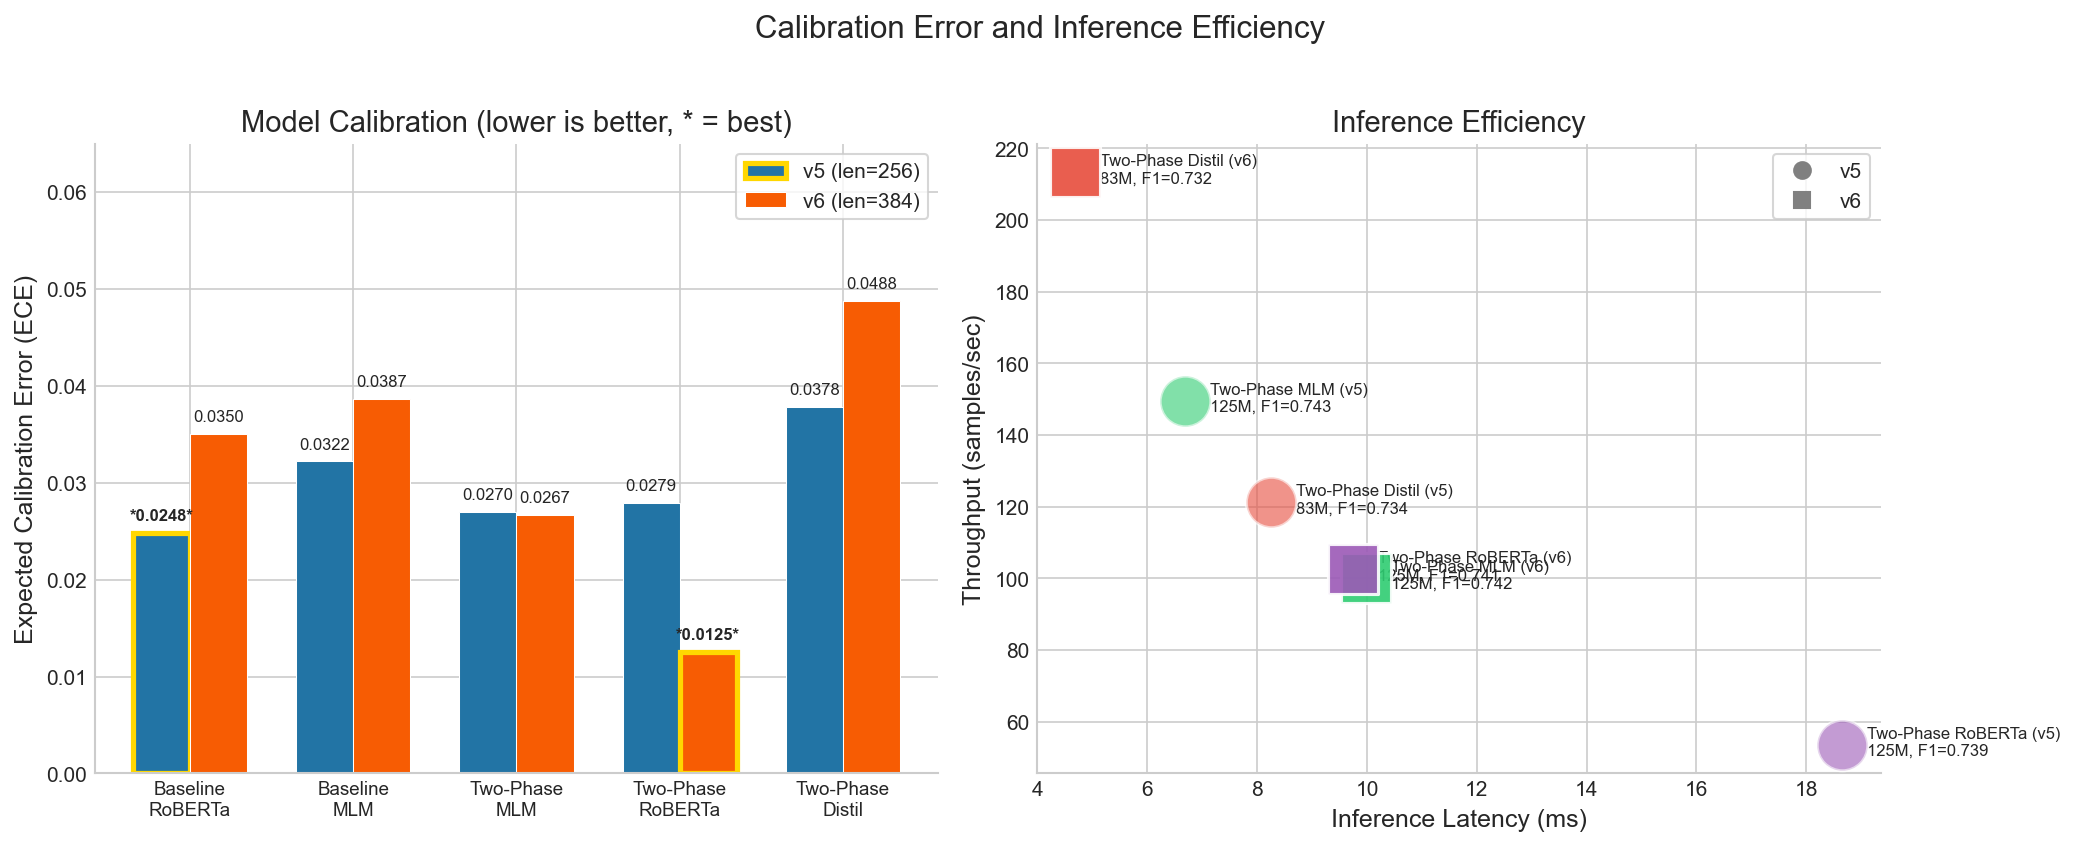

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: ECE grouped bar v5 vs v6 ────────────────────────────────────
model_names_short = ["Baseline\nRoBERTa", "Baseline\nMLM", "Two-Phase\nMLM", "Two-Phase\nRoBERTa", "Two-Phase\nDistil"]
x = np.arange(len(model_names_short))
width = 0.35

b1 = ax1.bar(x - width/2, v5_ece, width, label="v5 (len=256)", color="#2274A5",
             edgecolor="white", linewidth=0.5)
b2 = ax1.bar(x + width/2, v6_ece, width, label="v6 (len=384)", color="#F75C03",
             edgecolor="white", linewidth=0.5)

best_v5_ece = int(np.argmin(v5_ece))
best_v6_ece = int(np.argmin(v6_ece))

for j, (bar5, bar6) in enumerate(zip(b1, b2)):
    for bar, is_best in [(bar5, j == best_v5_ece), (bar6, j == best_v6_ece)]:
        txt = f"{bar.get_height():.4f}"
        if is_best:
            txt = f"*{txt}*"
            bar.set_edgecolor("#FFD700")
            bar.set_linewidth(2.5)
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 txt, ha="center", va="bottom", fontsize=8,
                 fontweight="bold" if is_best else "normal")

ax1.set_xticks(x)
ax1.set_xticklabels(model_names_short, fontsize=9)
ax1.set_ylabel("Expected Calibration Error (ECE)")
ax1.set_title("Model Calibration (lower is better, * = best)")
ax1.set_ylim(0, 0.065)
ax1.legend(frameon=True, fancybox=True)

# ── Right: Efficiency scatter (both v5 and v6 where available) ────────
eff_models = ["Two-Phase MLM", "Two-Phase RoBERTa", "Two-Phase Distil"]
markers_v5, markers_v6 = "o", "s"

for ver, eff_data, marker, alpha in [("v5", efficiency_v5, "o", 0.6),
                                       ("v6", efficiency_v6, "s", 0.9)]:
    for name in eff_models:
        if name not in eff_data:
            continue
        e = eff_data[name]
        lat = e["inference_latency_ms"]
        tp = e["throughput_samples_sec"]
        f1 = e["best_val_f1"]
        sz = e["params"]["total"] / 1e6
        ax2.scatter(lat, tp, s=f1 * 800, color=MODEL_COLORS[name],
                    alpha=alpha, edgecolors="white", linewidth=1.5,
                    marker=marker, zorder=5)
        ax2.annotate(f"{name} ({ver})\n{sz:.0f}M, F1={f1:.3f}",
                     (lat, tp), textcoords="offset points",
                     xytext=(12, -5), fontsize=8, ha="left")

# Legend for version markers
from matplotlib.lines import Line2D
legend_els = [Line2D([0], [0], marker="o", color="gray", markersize=8, linestyle="", label="v5"),
              Line2D([0], [0], marker="s", color="gray", markersize=8, linestyle="", label="v6")]
ax2.legend(handles=legend_els, frameon=True, fancybox=True)

ax2.set_xlabel("Inference Latency (ms)")
ax2.set_ylabel("Throughput (samples/sec)")
ax2.set_title("Inference Efficiency")

fig.suptitle("Calibration Error and Inference Efficiency", fontsize=15, y=1.02)
fig.tight_layout()
save_fig(fig, "fig7_calibration_efficiency")
plt.show()